In [1]:
import numpy as np
from matplotlib import pyplot as plt

**Cutoff frequency is a function of waveguide width.**

In [2]:
def cutoff_frequency(a):
    return 3e8/2/a

a = 0.214

f_c = cutoff_frequency(a)
f_0 = 805 * (1e6)

print('f_0: ', f_0 / 1e6, 'MHz')
print('f_c: ', f_c / 1e6, 'MHz')

f_0:  805.0 MHz
f_c:  700.9345794392524 MHz


**Space between modes is then a function of cutoff frequency. $$\lambda_z (f_0, f_c) = \frac{c}{\sqrt{(f_0^2 - f_c^2)}}$$**

In [3]:
def space_between_modes(f_c, f_0):
    return 3e8 * np.sqrt(1 / ((f_0**2) - (f_c**2)))

# for  a waveguide of length b = 600, the positions of modes is then

lambda_z = space_between_modes(f_c, f_0)
print(f'the wavelength of the resonant mode is: {lambda_z * 1000} [mm]')
print(f'therefore spacing between minima and maxima (a shift of pi/2 is): {lambda_z * 1000 / 2} [mm]')

# this matches simulation well

waveguide_length = 1200
#z = np.linspace(0, waveguide_length, 400)
#plt.plot(z, np.sin(2 * np.pi * 3e8 / lambda_z))

the wavelength of the resonant mode is: 757.8181106547528 [mm]
therefore spacing between minima and maxima (a shift of pi/2 is): 378.9090553273764 [mm]


**Regardless of modes, beam dynamics demand a spacing between cells that is matched to the particle bunch spacing (that's where our $f_0$ term comes from!). $$L = \frac{\beta c}{f_0} $$**

In [4]:
T = 1.24e-9
f_0 = 1 / T
beta = 0.9

print('f_0: ', f_0 / 1e6, 'MHz')

def bunch_spacing(beta, f_0):
    return beta * 3e8 / f_0

L = bunch_spacing(beta, f_0)
print('L: ', L * 1000, 'mm')

f_0:  806.4516129032257 MHz
L:  334.8 mm


**Sweeping across some values for the waveguide width, we find that the gap spacing demanded by the beam lies within a reasonable range of waveguide parameters. The range of "reasonable parameters" comes also from the fact that we are forced to remain working in the $TE_{010}$ mode, thus the cutoff frequency cannot restrict this.**

Text(0, 0.5, 'space between modes in mm')

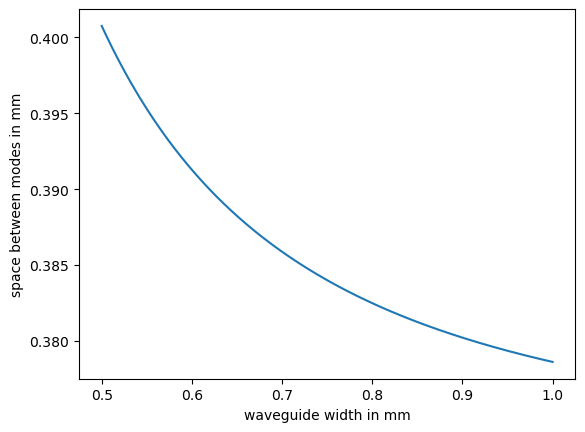

In [5]:
a_vals = np.linspace(0.5, 1.000, 400)
f_c_vals = cutoff_frequency(a_vals)

plt.plot(a_vals, space_between_modes(f_c_vals, f_0))
plt.xlabel('waveguide width in mm')
plt.ylabel('space between modes in mm')

In [14]:
#new_a = 0.365
new_a = 0.375
new_cutoff = cutoff_frequency(new_a)

print(f'For a waveguide width of {new_a} mm')
print(f'space between modes becomes {space_between_modes(new_cutoff, f_0)} mm')
print(f'halved space between modes becomes {space_between_modes(new_cutoff, f_0)/2} mm')

print(f'necessary spacing is 335 mm')
print(f'this halved is 167.5 mm')

print(f'and the difference between this and the necessary spacing is {space_between_modes(new_cutoff, f_0) - .335} mm')
print(f'this times 3 is then {(space_between_modes(new_cutoff, f_0) - .335) * 3} mm')
print(f'with maximum offset, {(space_between_modes(new_cutoff, f_0) - .335) * 3 - space_between_modes(new_cutoff, f_0) / 4} mm')
print(f'which must be compared to {space_between_modes(new_cutoff, f_0) / 4}')

For a waveguide width of 0.375 mm
space between modes becomes 0.42841224443765613 mm
halved space between modes becomes 0.21420612221882807 mm
necessary spacing is 335 mm
this halved is 167.5 mm
and the difference between this and the necessary spacing is 0.09341224443765611 mm
this times 3 is then 0.28023673331296833 mm
with maximum offset, 0.1731336722035543 mm
which must be compared to 0.10710306110941403
